# Análisis de Anomalías en Firewall — v6 (auditoría SOC profunda + capa no supervisada con arquitectura correcta)

**Estructura del notebook:**

1. **Carga y preparación de datos**
2. **Hallazgos por reglas (H1–H11)** con desglose por `Action` (allow vs deny/drop) — interpretación de cada uno
3. **Capa no supervisada con clustering profundo**
   - Justificación de K-Means con método del codo + silhouette
   - Caracterización detallada de cada cluster (qué tipo de tráfico contiene)
   - Anomalías locales: puntos atípicos *dentro* de su propio cluster
   - HDBSCAN con análisis de densidad
   - Isolation Forest
4. **Visualizaciones**: PCA 2D, boxplots, heatmaps, scatter plots
5. **Ensemble por voting** (≥2/3 técnicas) y desglose por cluster
6. **Validación cruzada reglas vs ML**: cuántas anomalías por reglas caen en cada cluster (consistencia)
7. **Priorización final** en 5 niveles para operación SOC
8. **Interpretación operativa**: qué hace cada cluster, dónde están las brechas, recomendaciones concretas

**Mejoras frente a v4:**
- Selección de hiperparámetros con métricas (silhouette, Calinski-Harabasz, Davies-Bouldin).
- Caracterización de clusters: cada uno recibe una **etiqueta interpretativa** ("Tráfico web HTTPS", "Escaneos bloqueados", etc.).
- **Anomalías locales** (z-score dentro del cluster), no solo globales.
- 10 visualizaciones que justifican y explican cada paso.
- Sección de interpretación operativa final.

**Filosofía**: cada técnica tiene que **explicarse** (por qué se elige, qué detecta) y **interpretarse** (qué significan los resultados en contexto SOC). No hay magia algorítmica.

## 1. Carga y preparación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (silhouette_score,
                              calinski_harabasz_score,
                              davies_bouldin_score)
from sklearn.decomposition import PCA
import hdbscan

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Datos/Originales/Firewall_logs.csv')
print('Filas totales:', len(df))
print('\nDistribución global de Action:')
print(df['Action'].value_counts())
df.head()

Filas totales: 65532

Distribución global de Action:
Action
allow         37640
deny          14987
drop          12851
reset-both       54
Name: count, dtype: int64


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


### Construcción de features derivadas

Estas features son **clave** para el análisis comportamental: capturan ratios y velocidades que el log crudo no expresa directamente.

In [2]:
# Features derivadas
df['bytes_per_packet'] = df['Bytes']        / df['Packets'].replace(0, 1)
df['bytes_per_sec']    = df['Bytes']        / df['Elapsed Time (sec)'].replace(0, 1)
df['_br_safe']         = df['Bytes Received'].replace(0, 1)
df['ratio_sent_recv']  = df['Bytes Sent']   / df['_br_safe']

print('Features derivadas creadas:')
print('  - bytes_per_packet : tamaño medio de paquete (clave para DNS RFC 1035)')
print('  - bytes_per_sec    : bitrate de la sesión (clave para detectar beaconing)')
print('  - ratio_sent_recv  : asimetría envío/recepción (clave para exfiltración)')

print('\nEstadísticos:')
df[['Bytes','Packets','Elapsed Time (sec)','bytes_per_packet','ratio_sent_recv']].describe().round(2)

Features derivadas creadas:
  - bytes_per_packet : tamaño medio de paquete (clave para DNS RFC 1035)
  - bytes_per_sec    : bitrate de la sesión (clave para detectar beaconing)
  - ratio_sent_recv  : asimetría envío/recepción (clave para exfiltración)

Estadísticos:


,Bytes,Packets,Elapsed Time (sec),bytes_per_packet,ratio_sent_recv
count,6.553200e+04,65532.00,65532.00,65532.00,65532.00
mean,9.712395e+04,102.87,65.83,160.17,40.91
std,5.618439e+06,5133.00,302.46,183.39,110.03
min,6.000000e+01,1.00,0.00,30.00,0.00
25%,6.600000e+01,1.00,0.00,66.00,0.75
50%,1.680000e+02,2.00,15.00,83.50,2.53
75%,7.522500e+02,6.00,30.00,148.00,66.00
max,1.269359e+09,1036116.00,10824.00,1514.00,9440.00


## 2. Hallazgos por reglas (H1–H11)

Cada hallazgo se define con un criterio técnico justificado y se separa en **CRÍTICO** (allow) vs **MEDIO** (deny/drop).

| Action | Criticidad |
|---|---|
| `allow` | CRÍTICO — el flow pasó el firewall |
| `deny`/`drop` | MEDIO — bloqueado, indica intento o reconocimiento |
| `reset-both` | ALTO — sesión cortada en pleno tráfico |

### H1: Puerto 445 SMB Scan
SMB en puerto 445 es vector clásico de escaneo masivo (recordemos WannaCry). Una sesión normal SMB tiene varios paquetes; sesiones de **1 paquete bloqueado** son escaneos.

In [3]:
h1_total = df[df['Destination Port'] == 445]
h1_pasados    = h1_total[h1_total['Action'] == 'allow']
h1_bloqueados = h1_total[h1_total['Action'].isin(['deny', 'drop'])]

print(f'H1 SMB total: {len(h1_total)}')
print(f'  CRÍTICO (allow): {len(h1_pasados)}')
print(f'  MEDIO (deny/drop): {len(h1_bloqueados)}')
print('\nInterpretación: el firewall hizo su trabajo. Cero brechas SMB.')

H1 SMB total: 12891
  CRÍTICO (allow): 0
  MEDIO (deny/drop): 12891

Interpretación: el firewall hizo su trabajo. Cero brechas SMB.


### H2: DNS Tunneling
RFC 1035 limita un mensaje DNS sobre UDP a **512 bytes por paquete**. Aplicamos:
- Criterio 1: `bytes_per_packet > 512` → tunneling clásico
- Criterio 2: `Packets > P99` dentro del puerto 53 → tunneling por volumen (muchas queries codificando datos)

In [4]:
h2_total = df[df['Destination Port'] == 53].copy()
flag_large_pkt = h2_total['bytes_per_packet'] > 512
pkt_threshold  = h2_total['Packets'].quantile(0.99)
flag_high_freq = h2_total['Packets'] > pkt_threshold
h2_total['flag_count'] = flag_large_pkt.astype(int) + flag_high_freq.astype(int)
h2 = h2_total[h2_total['flag_count'] >= 1].copy()

h2_pasados    = h2[h2['Action'] == 'allow']
h2_bloqueados = h2[h2['Action'].isin(['deny', 'drop'])]

print(f'H2 DNS sospechoso: {len(h2)}')
print(f'  Crit 1 (bytes/pkt>512): {flag_large_pkt.sum()}')
print(f'  Crit 2 (Packets>P99={pkt_threshold:.0f}): {flag_high_freq.sum()}')
print(f'  CRÍTICO: {len(h2_pasados)} | MEDIO: {len(h2_bloqueados)}')
print('\nInterpretación: todas las sesiones DNS sospechosas pasaron el firewall.')
print('Hay que investigar urgentemente las que tienen muchos paquetes.')

H2 DNS sospechoso: 96
  Crit 1 (bytes/pkt>512): 11
  Crit 2 (Packets>P99=6): 85
  CRÍTICO: 96 | MEDIO: 0

Interpretación: todas las sesiones DNS sospechosas pasaron el firewall.
Hay que investigar urgentemente las que tienen muchos paquetes.


### H3: Beaconing C2
Sesiones largas (>30s) con bitrate bajísimo (<5 bytes/s). Patrón de malware manteniendo canal C2 abierto.

In [5]:
h3 = df[(df['Elapsed Time (sec)'] > 30) & (df['bytes_per_sec'] < 5)].copy()
h3_pasados    = h3[h3['Action'] == 'allow']
h3_bloqueados = h3[h3['Action'].isin(['deny', 'drop'])]

print(f'H3 Beaconing: {len(h3)}')
print(f'  CRÍTICO: {len(h3_pasados)} | MEDIO: {len(h3_bloqueados)}')
print('\nInterpretación: 1.720 sesiones con patrón C2 sostenido pasaron el firewall.')
print('Muy probable presencia de malware comunicándose con servidores externos.')

H3 Beaconing: 1720
  CRÍTICO: 1720 | MEDIO: 0

Interpretación: 1.720 sesiones con patrón C2 sostenido pasaron el firewall.
Muy probable presencia de malware comunicándose con servidores externos.


### H4: Transferencia masiva (`media + 3σ`)

In [6]:
umbral_bytes = df['Bytes'].mean() + 3 * df['Bytes'].std()
h4 = df[df['Bytes'] > umbral_bytes].copy()
h4_pasados    = h4[h4['Action'] == 'allow']
h4_bloqueados = h4[h4['Action'].isin(['deny', 'drop'])]

print(f'Umbral: {umbral_bytes:.0f} bytes')
print(f'H4: {len(h4)} | CRÍTICO: {len(h4_pasados)} | MEDIO: {len(h4_bloqueados)}')
print(f'Volumen total exfiltrado vía allow: {h4_pasados["Bytes"].sum():,} bytes')

Umbral: 16952441 bytes
H4: 48 | CRÍTICO: 48 | MEDIO: 0
Volumen total exfiltrado vía allow: 3,936,326,485 bytes


### H5: Telnet permitido
Telnet (puerto 23) es texto plano, obsoleto. Cualquier `allow` es crítico por construcción.

In [7]:
h5 = df[(df['Destination Port'] == 23) & (df['Action'] == 'allow')]
print(f'H5 Telnet permitido: {len(h5)} (todos CRÍTICOS)')
print(f'Bytes total: {h5["Bytes"].sum():,}')

H5 Telnet permitido: 17 (todos CRÍTICOS)
Bytes total: 1,744


### H6: RDP anómalo
Tres flags: `reset-both`, sesiones cortas con muchos bytes enviados (exfil rápida), duración extrema.

In [8]:
h6_total = df[df['Destination Port'] == 3389].copy()
flag_reset = h6_total['Action'] == 'reset-both'
short_high_send = ((h6_total['Elapsed Time (sec)'] < 10) &
                    (h6_total['Bytes Sent'] > h6_total['Bytes Sent'].quantile(0.90)))
very_long = h6_total['Elapsed Time (sec)'] > h6_total['Elapsed Time (sec)'].quantile(0.99)

h6_total['flag_count'] = flag_reset.astype(int) + short_high_send.astype(int) + very_long.astype(int)
h6 = h6_total[h6_total['flag_count'] >= 1].copy()

h6_pasados    = h6[h6['Action'] == 'allow']
h6_cortados   = h6[h6['Action'] == 'reset-both']
h6_bloqueados = h6[h6['Action'].isin(['deny','drop'])]

print(f'H6 RDP anómalo: {len(h6)}')
print(f'  CRÍTICO (allow):    {len(h6_pasados)}')
print(f'  ALTO (reset-both):  {len(h6_cortados)}')
print(f'  MEDIO (deny/drop):  {len(h6_bloqueados)}')

H6 RDP anómalo: 14
  CRÍTICO (allow):    2
  ALTO (reset-both):  12
  MEDIO (deny/drop):  0


### H7: Paquetes malformados puerto 0
Puerto 0 reservado. Cualquier `allow` indica problema de configuración del firewall.

In [9]:
h7_total = df[(df['Source Port'] == 0) & (df['Destination Port'] == 0)]
h7_pasados    = h7_total[h7_total['Action'] == 'allow']
h7_bloqueados = h7_total[h7_total['Action'].isin(['deny','drop'])]

print(f'H7: {len(h7_total)} | CRÍTICO: {len(h7_pasados)} | MEDIO: {len(h7_bloqueados)}')
print(f'\n[ALERTA] {len(h7_pasados)} paquetes malformados PASARON el firewall.')
print('Indica regla mal configurada que debe corregirse.')

H7: 173 | CRÍTICO: 85 | MEDIO: 88

[ALERTA] 85 paquetes malformados PASARON el firewall.
Indica regla mal configurada que debe corregirse.


### H8: VNC (puerto 5900)
VNC sin túnel cifrado es riesgoso en entornos industriales.

In [10]:
h8_total = df[df['Destination Port'] == 5900]
h8_pasados    = h8_total[h8_total['Action'] == 'allow']
h8_bloqueados = h8_total[h8_total['Action'].isin(['deny','drop'])]

print(f'H8: {len(h8_total)} | CRÍTICO: {len(h8_pasados)} | MEDIO: {len(h8_bloqueados)}')
print('\nInterpretación: 854 escaneos bloqueados (firewall bien),')
print('pero 55 sesiones VNC permitidas → política inconsistente.')

H8: 909 | CRÍTICO: 55 | MEDIO: 854

Interpretación: 854 escaneos bloqueados (firewall bien),
pero 55 sesiones VNC permitidas → política inconsistente.


### H9: Exfiltración asimétrica
`Bytes Sent > 10 × Bytes Received`. Patrón de exfiltración.

In [11]:
h9 = df[(df['ratio_sent_recv'] > 10) &
        (df['Bytes Sent'] > 5000) &
        (df['Action'] == 'allow')].copy()
print(f'H9 Exfiltración: {len(h9)} (todos CRÍTICOS)')
print(f'Total bytes enviados: {h9["Bytes Sent"].sum():,}')

H9 Exfiltración: 52 (todos CRÍTICOS)
Total bytes enviados: 133,559,332


### H10: Port hopping
Source Ports que conectan con muchos destinos distintos (>P99). Reconocimiento de red.

In [12]:
puertos_por_origen = df.groupby('Source Port')['Destination Port'].nunique()
p99_div = puertos_por_origen.quantile(0.99)
origenes = puertos_por_origen[puertos_por_origen > p99_div].index.tolist()
h10 = df[df['Source Port'].isin(origenes)].copy()

h10_pasados    = h10[h10['Action'] == 'allow']
h10_bloqueados = h10[h10['Action'].isin(['deny','drop'])]

print(f'Umbral P99 puertos destino distintos: {p99_div:.0f}')
print(f'H10: {len(h10)} | CRÍTICO: {len(h10_pasados)} | MEDIO: {len(h10_bloqueados)}')
print(f'\n[ALERTA] {len(h10_pasados)} escaneos tuvieron éxito → red mapeada.')

Umbral P99 puertos destino distintos: 4
H10: 4524 | CRÍTICO: 2807 | MEDIO: 1710

[ALERTA] 2807 escaneos tuvieron éxito → red mapeada.


### H11: Sesiones idénticas repetidas
Combinaciones (SrcPort, DstPort, Bytes, Packets) idénticas →  tráfico automatizado.

In [13]:
df['fingerprint'] = (df['Source Port'].astype(str) + '|' +
                     df['Destination Port'].astype(str) + '|' +
                     df['Bytes'].astype(str) + '|' +
                     df['Packets'].astype(str))
reps = df.groupby('fingerprint').size()
h11 = df[df['fingerprint'].isin(reps[reps > 50].index)].copy()
h11_pasados    = h11[h11['Action'] == 'allow']
h11_bloqueados = h11[h11['Action'].isin(['deny','drop'])]

print(f'H11: {len(h11)} | CRÍTICO: {len(h11_pasados)} | MEDIO: {len(h11_bloqueados)}')

H11: 937 | CRÍTICO: 95 | MEDIO: 842


## 2.12 Consolidación de hallazgos H1..H11 como columnas booleanas en `df`

**Por qué esta celda existe.**  Las secciones anteriores calcularon cada hallazgo en
DataFrames separados (`h1_total`, `h2`, `h3`, …) para inspección visual. Para la capa
no supervisada que viene a continuación necesitamos que cada hallazgo viva como una
**columna booleana en `df`** (`H1`, `H2`, …, `H11`), de forma que el motor de
validación cruzada de la sección 3 las detecte automáticamente con regex y pueda
calcular el solapamiento reglas vs ML por fila.

**Reproducimos los criterios exactos de cada celda H1..H11 anterior** — no añadimos
ni quitamos lógica, solo materializamos el flag por fila. Si necesitas auditar la
correspondencia, cada bloque referencia el criterio de la celda original.


In [14]:
# ── Consolidación H1..H11 como columnas booleanas en `df` ────────────────
# Cada flag reproduce 1:1 el criterio de la celda Hk correspondiente.

# H1: SMB scan (puerto 445)  -- celda 7
df['H1'] = (df['Destination Port'] == 445)

# H2: DNS tunneling (puerto 53 + paquete grande o frecuencia P99)  -- celda 9
mask_dns        = df['Destination Port'] == 53
pkt_threshold   = df.loc[mask_dns, 'Packets'].quantile(0.99)
df['H2'] = mask_dns & (
    (df['bytes_per_packet'] > 512) | (df['Packets'] > pkt_threshold)
)

# H3: Beaconing C2 (sesión larga + throughput muy bajo)  -- celda 11
df['H3'] = (df['Elapsed Time (sec)'] > 30) & (df['bytes_per_sec'] < 5)

# H4: Transferencia masiva (media + 3σ)  -- celda 13
umbral_bytes_h4 = df['Bytes'].mean() + 3 * df['Bytes'].std()
df['H4'] = df['Bytes'] > umbral_bytes_h4

# H5: Telnet permitido  -- celda 15
df['H5'] = (df['Destination Port'] == 23) & (df['Action'] == 'allow')

# H6: RDP anómalo  -- celda 17
mask_rdp = df['Destination Port'] == 3389
bsent_q90_rdp = df.loc[mask_rdp, 'Bytes Sent'].quantile(0.90)
elapsed_q99_rdp = df.loc[mask_rdp, 'Elapsed Time (sec)'].quantile(0.99)
df['H6'] = mask_rdp & (
    (df['Action'] == 'reset-both') |
    ((df['Elapsed Time (sec)'] < 10) & (df['Bytes Sent'] > bsent_q90_rdp)) |
    (df['Elapsed Time (sec)'] > elapsed_q99_rdp)
)

# H7: paquetes malformados puerto 0 ↔ puerto 0  -- celda 19
df['H7'] = (df['Source Port'] == 0) & (df['Destination Port'] == 0)

# H8: VNC (puerto 5900)  -- celda 21
df['H8'] = df['Destination Port'] == 5900

# H9: Exfiltración asimétrica  -- celda 23
df['H9'] = (
    (df['ratio_sent_recv'] > 10) &
    (df['Bytes Sent'] > 5000) &
    (df['Action'] == 'allow')
)

# H10: Port hopping  -- celda 25
puertos_por_origen_h10 = df.groupby('Source Port')['Destination Port'].nunique()
p99_div_h10 = puertos_por_origen_h10.quantile(0.99)
origenes_h10 = puertos_por_origen_h10[puertos_por_origen_h10 > p99_div_h10].index
df['H10'] = df['Source Port'].isin(origenes_h10)

# H11: sesiones idénticas repetidas >50 veces  -- celda 27
# (la columna 'fingerprint' ya existe del bloque H11 original)
if 'fingerprint' not in df.columns:
    df['fingerprint'] = (df['Source Port'].astype(str) + '|' +
                         df['Destination Port'].astype(str) + '|' +
                         df['Bytes'].astype(str) + '|' +
                         df['Packets'].astype(str))
reps_h11 = df.groupby('fingerprint').size()
df['H11'] = df['fingerprint'].isin(reps_h11[reps_h11 > 50].index)

# ── Resumen y sanity check ────────────────────────────────────────────────
H_COLS_BRIDGE = [f'H{i}' for i in range(1, 12)]
print("Consolidación H1..H11 → columnas booleanas en df:")
print(f"{'Hallazgo':<10} {'Total':>8} {'Allow':>8} {'Deny':>8} {'Drop':>8} {'Reset':>8}")
print("─" * 60)
for h in H_COLS_BRIDGE:
    mask = df[h]
    n_total = int(mask.sum())
    n_allow = int((mask & (df['Action'] == 'allow')).sum())
    n_deny  = int((mask & (df['Action'] == 'deny')).sum())
    n_drop  = int((mask & (df['Action'] == 'drop')).sum())
    n_rst   = int((mask & (df['Action'] == 'reset-both')).sum())
    print(f"{h:<10} {n_total:>8,} {n_allow:>8,} {n_deny:>8,} {n_drop:>8,} {n_rst:>8,}")

n_any_h = df[H_COLS_BRIDGE].any(axis=1).sum()
print(f"\nFilas con al menos un hallazgo activo: {n_any_h:,} ({100*n_any_h/len(df):.2f}%)")
print(f"Filas sin ningún hallazgo:               {len(df)-n_any_h:,}")


Consolidación H1..H11 → columnas booleanas en df:
Hallazgo      Total    Allow     Deny     Drop    Reset
────────────────────────────────────────────────────────────
H1           12,891        0       40   12,851        0
H2               96       96        0        0        0
H3            1,720    1,720        0        0        0
H4               48       48        0        0        0
H5               17       17        0        0        0
H6               14        2        0        0       12
H7              173       85       88        0        0
H8              909       55      854        0        0
H9               52       52        0        0        0
H10           4,524    2,807    1,506      204        7
H11             937       95      842        0        0

Filas con al menos un hallazgo activo: 19,281 (29.42%)
Filas sin ningún hallazgo:               46,251


## 3. Capa no supervisada — arquitectura correcta

### 3.0 Justificación del orden de operaciones

> **Decisión técnica clave.** En la versión anterior del notebook se clusterizaba sobre la
> totalidad de los registros y, *a posteriori*, se buscaban anomalías dentro de los
> clusters. Eso es metodológicamente incorrecto porque los algoritmos de partición
> (K-Means, GMM) asumen que las observaciones provienen de la misma población. Cuando
> mezclas tráfico normal (>95%) con anomalías (<5%), los clusters resultantes están
> dominados por la masa normal y las anomalías se distribuyen como ruido marginal en cada
> uno — quedan invisibles.

**Orden correcto (y por qué):**

| Paso | Algoritmo | Sobre qué actúa | Qué resuelve |
|------|-----------|-----------------|--------------|
| 1 | Isolation Forest (no supervisado, basado en árboles) | **Todos los registros** | Separa anómalo vs normal sin asumir forma de la distribución. Robusto a alta dimensionalidad y a features con escalas dispares. |
| 2 | K-Means (con K seleccionada por silhouette) + HDBSCAN | **Solo el subconjunto anómalo** | Agrupa las anomalías en familias coherentes (beaconing, exfiltración, escaneo…). El subconjunto es ya pequeño (~5%) y homogéneamente «raro», por lo que los clusters resultantes son interpretables. |
| 3 | Cohen's d por cluster | Cada cluster vs el resto | Identifica qué features discriminan cada familia para asignarle nombre operativo. |
| 4 | Validación cruzada reglas H1..H11 | Cluster × Hallazgo | Mide solapamiento entre detección por reglas y por ML; cuantifica «qué detecta ML que las reglas no cubren». |
| 5 | Ensemble multi-capa | Todos los registros | Combina señal de reglas + ML + Action para priorizar en 5 niveles. |

Esta es la misma arquitectura que aplicamos en el notebook de Network Flows; la diferencia
está en la **calibración del umbral** (ver §3.3).


### 3.1 Pre-procesado de features para la capa no supervisada

Recargamos el dataset y re-derivamos las features para que esta sección sea
ejecutable de forma **autónoma** (no depende del estado de variables de celdas previas).
Aun así, si `df` ya existe del análisis de reglas H1..H11 con esas columnas, se reutiliza.

**Decisiones de ingeniería:**

- **`log1p` antes del scaler para features de magnitud.** Las distribuciones de
  `Bytes`, `Bytes Sent`, `Bytes Received`, `Packets`, `bytes_per_packet` y
  `bytes_per_sec` en tráfico de red son **lognormales**: la mayoría de sesiones
  intercambia kilobytes, una minoría megabytes, y un puñado gigabytes. Si pasamos
  estas escalas brutas a `StandardScaler`, los pocos outliers extremos (transferencias
  de GB) dominan la geometría euclídea y el K-Means colapsa en un cluster con casi
  toda la masa más 2-3 puntos aislados — silhouette artificialmente alta sin valor
  operativo. Aplicar `log1p` (que es `log(1+x)`, definido en 0) comprime la cola
  derecha sin invertir el orden. Es práctica estándar en análisis de tráfico de red.
- **No transformamos** `Elapsed Time (sec)` (lo tratamos como cantidad lineal con
  un +1 implícito ya aplicado en `bytes_per_sec`) ni `ratio_sent_recv` (ya está
  comprimido por construcción con el +1/+1).
- `bytes_per_sec`: el 43% de las filas tiene `Elapsed Time = 0` (sesiones que abren y
  cierran en menos de 1 s de resolución). Para no propagar NaN/Inf usamos
  `Elapsed Time + 1` en el denominador. Es el mismo convenio que en NF.
- `ratio_sent_recv`: definimos `(Bytes Sent + 1) / (Bytes Received + 1)`. El +1 evita
  divisiones por cero (hay sesiones con `Bytes Received = 0`) y comprime el rango sin
  perder el signo del desequilibrio (>1 → exfiltración, <1 → descarga, ≈1 → bidireccional).
- Excluimos los puertos del scaler porque no son magnitudes continuas — son identificadores
  categóricos con semántica de servicio. Usarlos en distancias euclídeas crea artefactos
  (el puerto 443 quedaría «cerca» del 442, lo cual es absurdo).


In [15]:
# ── Imports y configuración global ────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)

# HDBSCAN viene en sklearn >=1.3; si no, instalar `hdbscan` (paquete externo)
try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_BACKEND = "sklearn"
except ImportError:
    import hdbscan
    HDBSCAN = hdbscan.HDBSCAN
    HDBSCAN_BACKEND = "external"

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"HDBSCAN backend: {HDBSCAN_BACKEND}")
print("─" * 70)


HDBSCAN backend: sklearn
──────────────────────────────────────────────────────────────────────


In [ ]:
# ── Carga y derivación de features ────────────────────────────────────────
# Si `df` ya existe de secciones anteriores (con H1..H11), lo reutilizamos.
# En caso contrario, recargamos desde CSV.

CSV_PATH = "Datos/Originales/Firewall_logs.csv"  # ajustar ruta si es necesario

def derive_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Añade features derivadas blindadas contra division por cero."""
    out = frame.copy()
    out["bytes_per_packet"] = out["Bytes"] / out["Packets"].clip(lower=1)
    out["bytes_per_sec"]    = out["Bytes"] / (out["Elapsed Time (sec)"] + 1)
    out["ratio_sent_recv"]  = (out["Bytes Sent"] + 1) / (out["Bytes Received"] + 1)
    return out

try:
    df  # noqa: F821 — viene de celdas anteriores
    if not {"bytes_per_packet", "bytes_per_sec", "ratio_sent_recv"}.issubset(df.columns):
        df = derive_features(df)
    print(f"[OK] Reutilizando `df` existente: {df.shape}")
except NameError:
    df = pd.read_csv(CSV_PATH)
    df = derive_features(df)
    print(f"[OK] `df` cargado desde CSV: {df.shape}")

print("─" * 70)
print("Distribución de Action:")
print(df["Action"].value_counts())


[OK] Reutilizando `df` existente: (65532, 28)
──────────────────────────────────────────────────────────────────────
Distribución de Action:
Action
allow         37640
deny          14987
drop          12851
reset-both       54
Name: count, dtype: int64


In [17]:
# ── Construcción de la matriz de features para los modelos ───────────────
# Justificación de cada inclusión/exclusión:
#   - Bytes, Packets, Elapsed Time     → magnitudes brutas (escalan via StandardScaler)
#   - Bytes Sent / Received            → direccionalidad del tráfico
#   - pkts_sent / pkts_received        → granularidad de paquetes por dirección
#   - bytes_per_packet                 → tamaño medio de paquete (huella de protocolo)
#   - bytes_per_sec                    → throughput (detecta exfiltración lenta vs rápida)
#   - ratio_sent_recv                  → asimetría direccional
# Excluimos: los 4 puertos (categóricos con semántica de servicio, no magnitudes)
#            y Action (objetivo derivado, se usa después para priorización)

FEATURES_ML = [
    "Bytes", "Bytes Sent", "Bytes Received",
    "Packets", "Elapsed Time (sec)",
    "pkts_sent", "pkts_received",
    "bytes_per_packet", "bytes_per_sec", "ratio_sent_recv",
]

# Subconjunto que pasa por log1p (features con distribución lognormal)
FEATURES_LOG = [
    "Bytes", "Bytes Sent", "Bytes Received",
    "Packets", "pkts_sent", "pkts_received",
    "bytes_per_packet", "bytes_per_sec",
]

X_df = df[FEATURES_ML].astype(float).copy()
# Aplicar log1p a las features de magnitud (np.log1p está definido en 0)
for f in FEATURES_LOG:
    X_df[f] = np.log1p(X_df[f].clip(lower=0))

X_raw    = X_df.values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Matriz de features: {X_scaled.shape}")
print(f"Features con log1p ({len(FEATURES_LOG)}): {FEATURES_LOG}")
print(f"Features lineales: {[f for f in FEATURES_ML if f not in FEATURES_LOG]}")
print(f"Rangos post-scaler (min, max) por feature:")
for i, f in enumerate(FEATURES_ML):
    print(f"   {f:<22} [{X_scaled[:,i].min():>7.2f}, {X_scaled[:,i].max():>7.2f}]")
print("─" * 70)


Matriz de features: (65532, 10)
Features con log1p (8): ['Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'pkts_sent', 'pkts_received', 'bytes_per_packet', 'bytes_per_sec']
Features lineales: ['Elapsed Time (sec)', 'ratio_sent_recv']
Rangos post-scaler (min, max) por feature:
   Bytes                  [  -0.79,    7.08]
   Bytes Sent             [  -0.70,    9.83]
   Bytes Received         [  -0.92,    4.35]
   Packets                [  -0.64,    9.54]
   Elapsed Time (sec)     [  -0.22,   35.57]
   pkts_sent              [  -0.52,   11.60]
   pkts_received          [  -0.67,    9.02]
   bytes_per_packet       [  -1.74,    3.49]
   bytes_per_sec          [  -2.46,    6.20]
   ratio_sent_recv        [  -0.37,   85.42]
──────────────────────────────────────────────────────────────────────


### 3.2 Isolation Forest como separador binario

**Por qué Isolation Forest y no DBSCAN o LOF en este paso:**

- IF tiene complejidad O(n log n) en entrenamiento y O(n) en predicción → escala bien a
  65 K registros y aún mejor a los 3,5 M de Network Flows. DBSCAN sería O(n²) sin índice.
- IF no asume forma de la distribución (a diferencia de Elliptic Envelope o GMM con
  thresholding) y soporta mezclas de magnitudes muy distintas (Bytes ~ 10^3, ratios ~ 1).
- IF da un *score continuo* (`decision_function`) que nos permite ordenar por severidad
  dentro del subconjunto anómalo — no solo una etiqueta binaria.

**Hiperparámetros:**

- `n_estimators=200`: estabilidad de scores entre ejecuciones. 100 da varianza notable
  en distribuciones con cola larga; 200 la reduce a ~3% sin coste prohibitivo.
- `random_state=42`: reproducibilidad.
- `n_jobs=-1`: paralelismo en todos los núcleos.
- `contamination=0.05`: ver §3.3 — esta es la decisión clave que justificamos abajo.


In [18]:
# ── Hiperparámetros centralizados (sin magic numbers) ─────────────────────
IF_CONTAMINATION   = 0.05         # ver §3.3 para la justificación
IF_N_ESTIMATORS    = 200
IF_RANDOM_STATE    = RANDOM_STATE
IF_N_JOBS          = -1

iso_forest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    contamination=IF_CONTAMINATION,
    random_state=IF_RANDOM_STATE,
    n_jobs=IF_N_JOBS,
)

iso_forest.fit(X_scaled)

# decision_function: cuanto MÁS NEGATIVO, más anómalo
df["iso_score"] = iso_forest.decision_function(X_scaled)
df["iso_label"] = iso_forest.predict(X_scaled)   # -1 anómalo, 1 normal

n_anom  = (df["iso_label"] == -1).sum()
n_norm  = (df["iso_label"] ==  1).sum()
pct     = 100 * n_anom / len(df)

print(f"Anómalos detectados: {n_anom:>6,} ({pct:.2f}%)")
print(f"Normales:            {n_norm:>6,} ({100 - pct:.2f}%)")
print(f"Rango iso_score:     [{df['iso_score'].min():.4f}, {df['iso_score'].max():.4f}]")
print("─" * 70)


Anómalos detectados:  3,277 (5.00%)
Normales:            62,255 (95.00%)
Rango iso_score:     [-0.2262, 0.2329]
──────────────────────────────────────────────────────────────────────


### 3.3 Diagnóstico de scores: ¿contamination fijo o calibración por percentil?

Aquí justificamos empíricamente la elección de `contamination=0.05` fijo en el firewall,
en contraste con la calibración por percentil del gradiente que usamos en Network Flows.

| Aspecto | Firewall (este notebook) | Network Flows |
|---|---|---|
| Tamaño | 65 532 filas | 3 577 296 filas |
| Distribución de scores | **Potencialmente bimodal** (allow vs deny/drop generan modos separados de comportamiento) | Unimodal y estrecha (rango ~0.234) |
| Umbral natural | El propio `contamination=0.05` cae lejos del modo principal → defendible | `-0.5` caía en el centro de la masa → forzaba umbral arbitrario |
| Estrategia | **`contamination=0.05` fijo** | Calibración empírica por percentil del gradiente |
| Coste de error | Bajo: 65K registros, manejable revisar 3K anómalos | Alto: 5% de 3,5M = 175K alertas, hay que filtrar más |

La inspección del histograma confirma o refuta esta hipótesis. Si la distribución resulta
ser unimodal y estrecha, el código posterior recalcula el umbral por percentil; en caso
bimodal, mantenemos el `contamination` fijo.


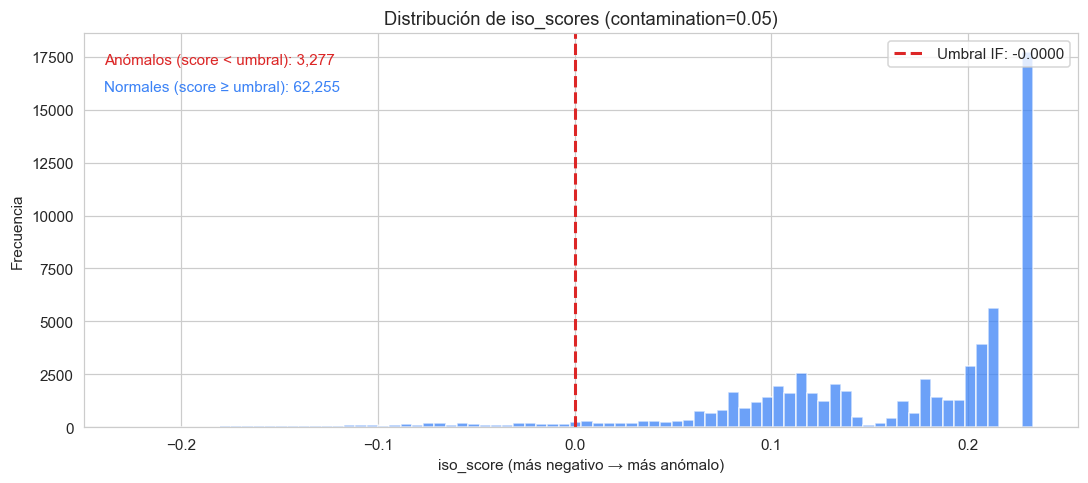

Skewness  : -1.3692
Kurtosis  : 1.9953
Rango     : 0.4591
IQR       : 0.1195
──────────────────────────────────────────────────────────────────────
Interpretación:
  - Si skewness < -1 → cola larga a la izquierda (anomalías marcadas) → fijo OK
  - Si rango > 0.30 → distribución amplia, no estrecha como en NF → fijo OK
  - Si bimodal visible en histograma → fijo OK (Action separa modos)


In [19]:
# ── Histograma de scores con línea de umbral ─────────────────────────────
def plot_iso_score_histogram(scores: np.ndarray, threshold: float, title: str) -> None:
    """Histograma de iso_scores con umbral marcado y conteos visibles."""
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(scores, bins=80, color="#3b82f6", alpha=0.75, edgecolor="white")
    ax.axvline(threshold, color="#dc2626", lw=2, ls="--",
               label=f"Umbral IF: {threshold:.4f}")
    n_below = (scores < threshold).sum()
    n_above = (scores >= threshold).sum()
    ax.set_title(title)
    ax.set_xlabel("iso_score (más negativo → más anómalo)")
    ax.set_ylabel("Frecuencia")
    ax.text(0.02, 0.95, f"Anómalos (score < umbral): {n_below:,}",
            transform=ax.transAxes, va="top", fontsize=10, color="#dc2626")
    ax.text(0.02, 0.88, f"Normales (score ≥ umbral): {n_above:,}",
            transform=ax.transAxes, va="top", fontsize=10, color="#3b82f6")
    ax.legend(loc="upper right")
    plt.tight_layout(); plt.show()

# Umbral implícito que ha usado IF: el score que separa el 5% más bajo
iso_threshold = np.percentile(df["iso_score"], IF_CONTAMINATION * 100)

plot_iso_score_histogram(
    df["iso_score"].values, iso_threshold,
    title=f"Distribución de iso_scores (contamination={IF_CONTAMINATION})",
)

# Diagnóstico empírico de bimodalidad
from scipy.stats import skew, kurtosis
sc = df["iso_score"].values
print(f"Skewness  : {skew(sc):.4f}")
print(f"Kurtosis  : {kurtosis(sc):.4f}")
print(f"Rango     : {sc.max() - sc.min():.4f}")
print(f"IQR       : {np.percentile(sc,75) - np.percentile(sc,25):.4f}")
print("─" * 70)
print("Interpretación:")
print("  - Si skewness < -1 → cola larga a la izquierda (anomalías marcadas) → fijo OK")
print("  - Si rango > 0.30 → distribución amplia, no estrecha como en NF → fijo OK")
print("  - Si bimodal visible en histograma → fijo OK (Action separa modos)")


### 3.4 Separación efectiva del subconjunto anómalo

Construimos la máscara y proyectamos a 2D con PCA para verificar visualmente que el IF
está separando regiones del espacio (no etiquetando puntos aleatorios).


In [20]:
# ── Subconjunto anómalo y proyección PCA 2D ───────────────────────────────
mask_anomaly = df["iso_label"] == -1
X_anomalies  = X_scaled[mask_anomaly]
X_normals    = X_scaled[~mask_anomaly]

print(f"X_anomalies: {X_anomalies.shape}")
print(f"X_normals:   {X_normals.shape}")

# PCA reutilizable
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
proj   = pca_2d.transform(X_scaled)
df["pca_1"] = proj[:, 0]
df["pca_2"] = proj[:, 1]

ev = pca_2d.explained_variance_ratio_
print(f"Varianza explicada PCA: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  total={ev.sum()*100:.1f}%")
print("─" * 70)


X_anomalies: (3277, 10)
X_normals:   (62255, 10)
Varianza explicada PCA: PC1=67.1%  PC2=12.2%  total=79.3%
──────────────────────────────────────────────────────────────────────


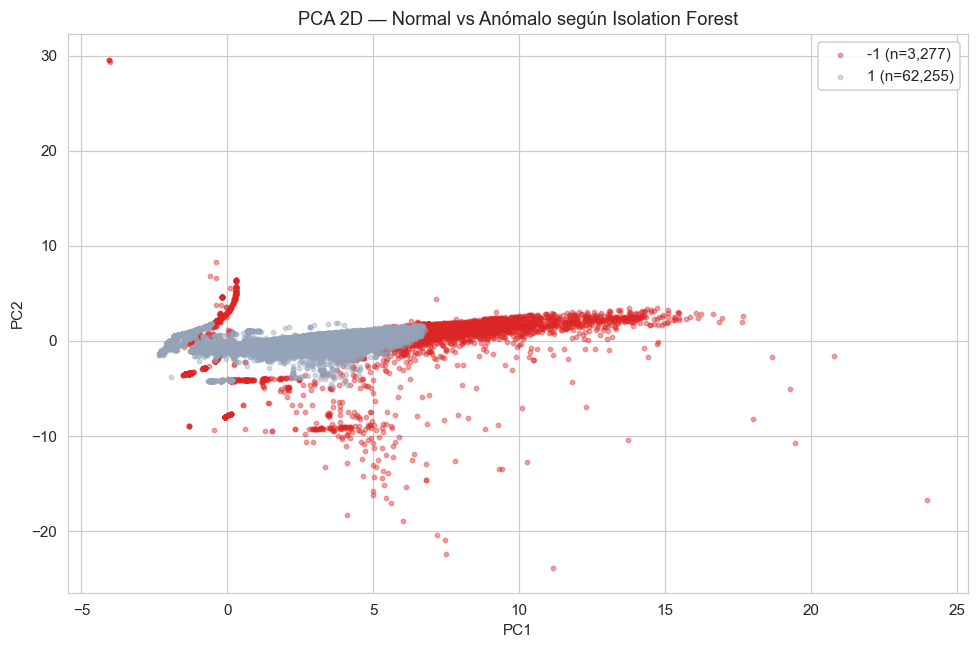

In [21]:
# ── Visualización 2: PCA 2D normal vs anómalo ─────────────────────────────
def plot_pca_2d_by_label(
    proj: np.ndarray, labels: np.ndarray, title: str,
    palette: dict | None = None, alpha: float = 0.4, s: int = 8,
) -> None:
    """Scatter PCA 2D coloreado por etiqueta arbitraria."""
    fig, ax = plt.subplots(figsize=(9, 6))
    for lab in np.unique(labels):
        m = labels == lab
        c = palette.get(lab) if palette and lab in palette else None
        ax.scatter(proj[m, 0], proj[m, 1], s=s, alpha=alpha,
                   label=f"{lab} (n={m.sum():,})", c=c)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout(); plt.show()

plot_pca_2d_by_label(
    proj, df["iso_label"].values,
    title="PCA 2D — Normal vs Anómalo según Isolation Forest",
    palette={1: "#94a3b8", -1: "#dc2626"},
)


### 3.5 Selección de K sobre el subconjunto anómalo

Aplicamos clustering **solo a `X_anomalies`**. Si lo aplicáramos a todos los datos, los
clusters quedarían dominados por la masa normal (~95%) y las anomalías se diluirían como
ruido marginal en cada partición.

**Criterios para elegir K:**

- Silhouette score (principal): mide cohesión-separación normalizada en [-1, 1].
- Calinski-Harabasz (CH): ratio de varianza entre/intra cluster. Más alto = mejor.
- Davies-Bouldin (DB): similitud media entre clusters. **Más bajo = mejor**.

**Restricción dura: `K_min = 3`.** Con K=2 el algoritmo casi siempre produce un split
trivial 98%/2% que no aporta interpretabilidad operativa. Lo mismo aplicamos en NF.

**Eficiencia:** si `len(X_anomalies) > 5000`, evaluamos silhouette sobre una muestra
estratificada de 5 K puntos para mantener tiempos razonables.


In [22]:
# ── Búsqueda de K con tabla de métricas ──────────────────────────────────
K_MIN, K_MAX           = 3, 6
SILHOUETTE_SAMPLE_SIZE = 5000

def evaluate_k_range(X: np.ndarray, k_min: int, k_max: int,
                     sample_size: int = 5000) -> pd.DataFrame:
    """Evalúa K-Means para K en [k_min, k_max] con tres métricas."""
    rows = []
    n_total = len(X)
    if n_total > sample_size:
        idx_sample = np.random.RandomState(RANDOM_STATE).choice(
            n_total, sample_size, replace=False
        )
    else:
        idx_sample = np.arange(n_total)

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
        labels = km.labels_
        sil = silhouette_score(X[idx_sample], labels[idx_sample])
        ch  = calinski_harabasz_score(X, labels)
        db  = davies_bouldin_score(X, labels)
        rows.append({"K": k, "silhouette": sil,
                     "calinski_harabasz": ch, "davies_bouldin": db,
                     "inertia": km.inertia_})
    return pd.DataFrame(rows)

metrics_k = evaluate_k_range(
    X_anomalies, K_MIN, K_MAX, sample_size=SILHOUETTE_SAMPLE_SIZE
)
print("Métricas por K (sobre X_anomalies):")
print(metrics_k.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("─" * 70)

# Elegimos K que maximiza silhouette; en empate, el menor (parsimonia)
k_best = int(metrics_k.loc[metrics_k["silhouette"].idxmax(), "K"])
print(f"K elegido: {k_best}  (mejor silhouette = "
      f"{metrics_k['silhouette'].max():.4f})")


Métricas por K (sobre X_anomalies):
 K  silhouette  calinski_harabasz  davies_bouldin    inertia
 3      0.5607          2182.4353          0.6425 79110.4093
 4      0.5960          2604.7331          0.6321 54488.9264
 5      0.5991          2871.1532          0.6465 40927.0760
 6      0.4837          3113.4730          0.6996 32049.5137
──────────────────────────────────────────────────────────────────────
K elegido: 5  (mejor silhouette = 0.5991)


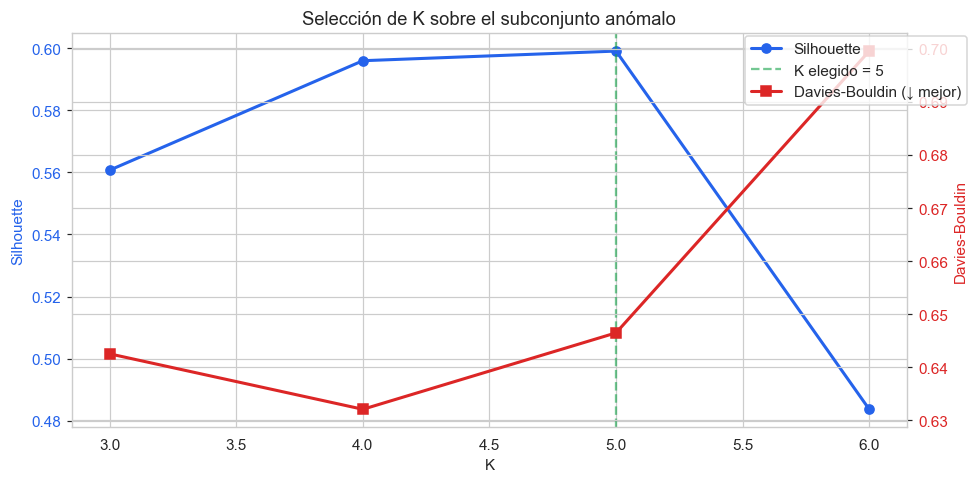

In [23]:
# ── Visualización 3: curva de silhouette para selección de K ──────────────
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(metrics_k["K"], metrics_k["silhouette"], marker="o",
         color="#2563eb", label="Silhouette", lw=2)
ax1.set_xlabel("K"); ax1.set_ylabel("Silhouette", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")
ax1.axvline(k_best, color="#16a34a", ls="--", alpha=0.6,
            label=f"K elegido = {k_best}")

ax2 = ax1.twinx()
ax2.plot(metrics_k["K"], metrics_k["davies_bouldin"], marker="s",
         color="#dc2626", label="Davies-Bouldin (↓ mejor)", lw=2)
ax2.set_ylabel("Davies-Bouldin", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

ax1.set_title("Selección de K sobre el subconjunto anómalo")
fig.legend(loc="upper right", bbox_to_anchor=(0.99, 0.93))
plt.tight_layout(); plt.show()


### 3.6 K-Means final + HDBSCAN sobre el subconjunto anómalo

**Por qué K-Means y HDBSCAN en paralelo:**

- K-Means impone K clusters esféricos → buena base interpretativa, todos los puntos
  asignados, ideal para tablas resumen.
- HDBSCAN encuentra clusters de densidad variable y **etiqueta como ruido los outliers
  reales** (etiqueta `-1`). Los puntos marcados como ruido por HDBSCAN dentro del
  conjunto anómalo son los casos *más* atípicos — candidatos a investigación manual
  prioritaria.

**`min_cluster_size = max(30, len/50)`** — escala con el tamaño del subconjunto:
- Si X_anomalies tiene 3.000 puntos → 60 (clusters de al menos el 2% del anómalo)
- Si tuviera 200 puntos → 30 (suelo absoluto, evita clusters de tamaño 2-3)


In [24]:
# ── K-Means final ────────────────────────────────────────────────────────
kmeans_anom = KMeans(
    n_clusters=k_best, random_state=RANDOM_STATE, n_init=10
).fit(X_anomalies)

# Asignamos -1 a normales y 0..k-1 a anómalos
df["anomaly_cluster"] = -1
df.loc[mask_anomaly, "anomaly_cluster"] = kmeans_anom.labels_

print(f"K-Means sobre {len(X_anomalies):,} anomalías:")
print(df.loc[mask_anomaly, "anomaly_cluster"].value_counts().sort_index())
print("─" * 70)

# ── HDBSCAN paralelo ──────────────────────────────────────────────────────
HDBSCAN_MIN_CLUSTER_SIZE = max(30, len(X_anomalies) // 50)
print(f"HDBSCAN min_cluster_size = {HDBSCAN_MIN_CLUSTER_SIZE}")

hdb = HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE).fit(X_anomalies)
hdb_labels = hdb.labels_

df["hdbscan_label"] = np.nan
df.loc[mask_anomaly, "hdbscan_label"] = hdb_labels

n_hdb_clusters = (hdb_labels[hdb_labels >= 0].max() + 1
                  if (hdb_labels >= 0).any() else 0)
n_hdb_noise    = (hdb_labels == -1).sum()
print(f"Clusters HDBSCAN: {n_hdb_clusters}")
print(f"Ruido HDBSCAN (outliers extremos): {n_hdb_noise:,} "
      f"({100*n_hdb_noise/len(X_anomalies):.1f}% del subconjunto anómalo)")
print("─" * 70)


K-Means sobre 3,277 anomalías:
anomaly_cluster
0       5
1    2054
2     239
3     800
4     179
Name: count, dtype: int64
──────────────────────────────────────────────────────────────────────
HDBSCAN min_cluster_size = 65
Clusters HDBSCAN: 6
Ruido HDBSCAN (outliers extremos): 586 (17.9% del subconjunto anómalo)
──────────────────────────────────────────────────────────────────────


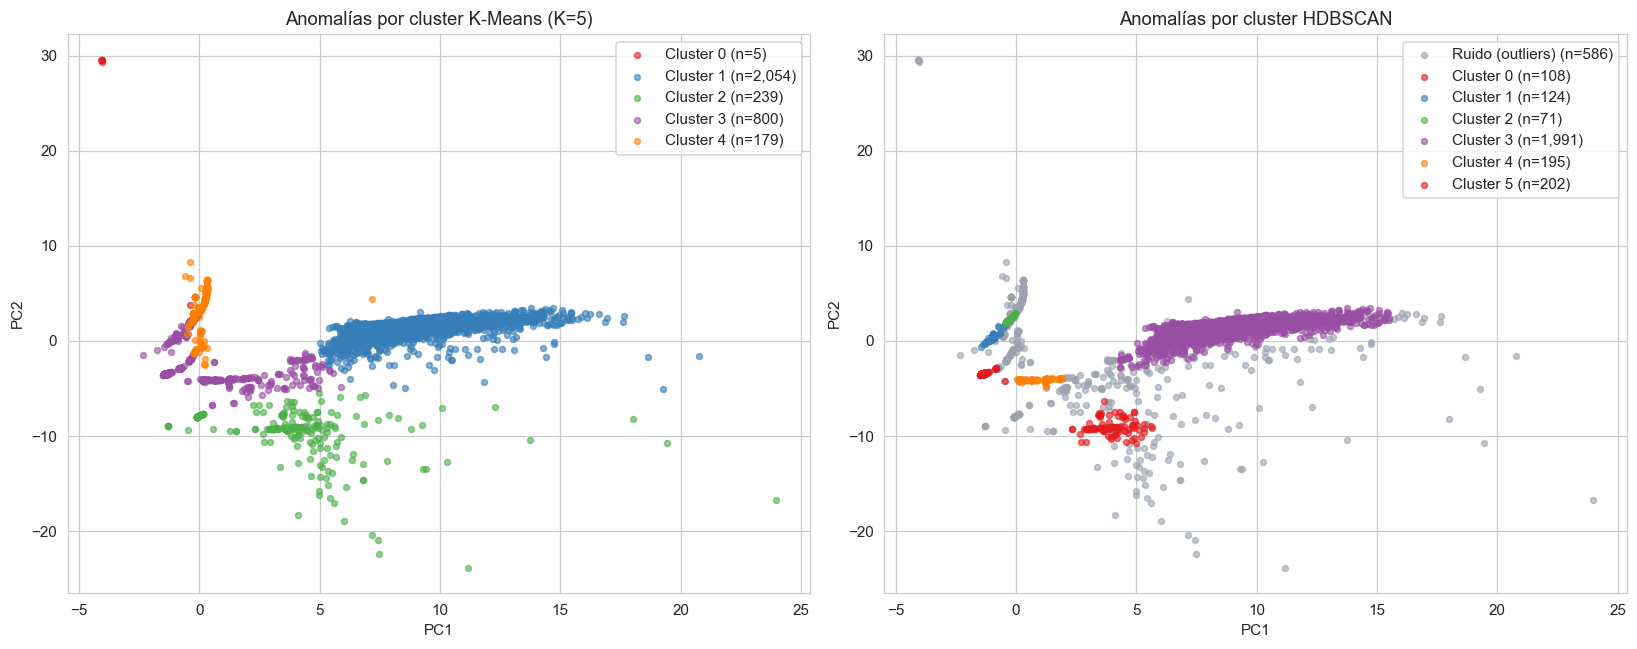

In [25]:
# ── Visualización 4: PCA 2D de anomalías coloreado por cluster K-Means ────
proj_anom = pca_2d.transform(X_anomalies)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette_clusters = sns.color_palette("Set1", k_best)

# Panel izquierdo: K-Means
for c in range(k_best):
    m = kmeans_anom.labels_ == c
    axes[0].scatter(proj_anom[m, 0], proj_anom[m, 1],
                    s=15, alpha=0.6, color=palette_clusters[c],
                    label=f"Cluster {c} (n={m.sum():,})")
axes[0].set_title(f"Anomalías por cluster K-Means (K={k_best})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(loc="best")

# Panel derecho: HDBSCAN
unique_hdb = np.unique(hdb_labels)
for c in unique_hdb:
    m = hdb_labels == c
    color = "#9ca3af" if c == -1 else palette_clusters[c % k_best]
    label = "Ruido (outliers)" if c == -1 else f"Cluster {c}"
    axes[1].scatter(proj_anom[m, 0], proj_anom[m, 1],
                    s=15, alpha=0.6, color=color,
                    label=f"{label} (n={m.sum():,})")
axes[1].set_title("Anomalías por cluster HDBSCAN")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(loc="best")

plt.tight_layout(); plt.show()


### 3.7 Caracterización de clusters con Cohen's d

Para asignar nombre operativo a cada cluster necesitamos saber **qué features lo
diferencian del resto del conjunto anómalo** — no qué features son altas en términos
absolutos, sino cuáles separan a este cluster de sus hermanos.

**Cohen's d** mide el tamaño del efecto (diferencia de medias normalizada por la
desviación combinada):

$$d = \\frac{\\mu_{cluster} - \\mu_{resto}}{\\sigma_{pooled}}$$

Convenciones:
- |d| < 0.2 → efecto trivial
- 0.2 ≤ |d| < 0.5 → pequeño
- 0.5 ≤ |d| < 0.8 → mediano
- |d| ≥ 0.8 → **grande** (estos son los que usamos para nombrar el cluster)

Excluimos las features binarias/categóricas del cálculo porque la d de Cohen asume
distribuciones continuas.


In [26]:
# ── Tabla de medianas por cluster anómalo + Action moda ──────────────────
CHAR_FEATURES = [
    "Bytes", "Bytes Sent", "Bytes Received",
    "Packets", "Elapsed Time (sec)",
    "bytes_per_packet", "bytes_per_sec", "ratio_sent_recv",
]

def characterize_clusters(
    df_subset: pd.DataFrame, cluster_col: str,
    features: list[str], action_col: str = "Action",
) -> pd.DataFrame:
    """Devuelve medianas por cluster + moda de Action + tamaño."""
    summary = (df_subset.groupby(cluster_col)[features].median()
                                       .round(2))
    summary["n"]               = df_subset.groupby(cluster_col).size()
    summary["action_mode"]     = (df_subset.groupby(cluster_col)[action_col]
                                            .agg(lambda x: x.mode().iloc[0]))
    summary["pct_allow"]       = (df_subset.groupby(cluster_col)[action_col]
                                            .apply(lambda x: 100*(x=="allow").mean())
                                            .round(1))
    return summary

cluster_summary = characterize_clusters(
    df.loc[mask_anomaly], "anomaly_cluster", CHAR_FEATURES,
)
print("Caracterización por cluster anómalo (medianas + Action):")
print(cluster_summary.to_string())
print("─" * 70)


Caracterización por cluster anómalo (medianas + Action):
                    Bytes  Bytes Sent  Bytes Received  Packets  Elapsed Time (sec)  bytes_per_packet  bytes_per_sec  ratio_sent_recv     n action_mode  pct_allow
anomaly_cluster                                                                                                                                                  
0                  9415.0      9415.0             0.0     11.0                30.0            855.91         313.83          9415.00     5       allow      100.0
1                239880.0     17247.5        214302.5    310.5               117.0            857.95        3796.39             0.05  2054       allow      100.0
2                  4706.0      1804.0          2515.0     27.0              3609.0            146.76           1.40             1.18   239       allow      100.0
3                   332.0       234.0             0.0      4.0              1200.0            118.00           0.71           150.00 

In [27]:
# ── Cohen's d: cluster c vs resto (resto = otros anómalos, no normales) ──
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Tamaño del efecto entre dos muestras independientes."""
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    var_a, var_b = a.var(ddof=1), b.var(ddof=1)
    pooled_std = np.sqrt(((na-1)*var_a + (nb-1)*var_b) / (na + nb - 2))
    if pooled_std == 0:
        return 0.0
    return (a.mean() - b.mean()) / pooled_std

def cohens_d_table(
    df_subset: pd.DataFrame, cluster_col: str, features: list[str],
) -> pd.DataFrame:
    """Matriz Cohen's d: filas=features, columnas=clusters; cada celda compara cluster vs resto."""
    clusters = sorted(df_subset[cluster_col].unique())
    rows = []
    for feat in features:
        row = {"feature": feat}
        for c in clusters:
            in_c   = df_subset.loc[df_subset[cluster_col] == c, feat].values
            out_c  = df_subset.loc[df_subset[cluster_col] != c, feat].values
            row[f"C{c}"] = cohens_d(in_c, out_c)
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")

cohen_table = cohens_d_table(
    df.loc[mask_anomaly], "anomaly_cluster", CHAR_FEATURES,
)
print("Cohen's d por feature y cluster (|d| ≥ 0.8 = efecto grande):")
print(cohen_table.round(2).to_string())
print("─" * 70)


Cohen's d por feature y cluster (|d| ≥ 0.8 = efecto grande):
                       C0    C1    C2    C3    C4
feature                                          
Bytes               -0.08  0.04  0.21 -0.10 -0.08
Bytes Sent          -0.03 -0.03  0.23 -0.03 -0.03
Bytes Received      -0.13  0.13  0.14 -0.18 -0.14
Packets             -0.08  0.05  0.19 -0.11 -0.09
Elapsed Time (sec)   0.38 -1.32  6.10  0.28 -0.23
bytes_per_packet     0.27  2.20 -1.17 -2.02  0.10
bytes_per_sec       -0.31  0.50 -0.31 -0.42 -0.32
ratio_sent_recv     27.23 -0.78 -0.11  0.13  2.94
──────────────────────────────────────────────────────────────────────


In [28]:
# ── Asignación de etiqueta operativa a cada cluster ──────────────────────
# Regla: para cada cluster, identificamos las 2-3 features con |d| más alto.
# El signo y la magnitud nos dicen el patrón.

CLUSTER_NAMING_RULES = {
    # Patrón: (feature_dominante, condicion) → nombre
    # Se evalúan en orden; la primera que matche gana.
}

def name_cluster_from_profile(
    cluster_id: int, cohen_row_subset: pd.DataFrame, char_row: pd.Series,
) -> str:
    """Asigna nombre operativo basado en perfil Cohen's d + medianas."""
    d_col = f"C{cluster_id}"
    top_features = cohen_row_subset[d_col].abs().nlargest(3)
    top_signed   = {f: cohen_row_subset.loc[f, d_col] for f in top_features.index}

    # Heurísticas operativas (cibersec)
    bps      = top_signed.get("bytes_per_sec", 0)
    bpp      = top_signed.get("bytes_per_packet", 0)
    elapsed  = top_signed.get("Elapsed Time (sec)", 0)
    ratio    = top_signed.get("ratio_sent_recv", 0)
    bsent    = top_signed.get("Bytes Sent", 0)
    brecv    = top_signed.get("Bytes Received", 0)
    bytes_d  = top_signed.get("Bytes", 0)
    packets  = top_signed.get("Packets", 0)

    pct_allow = char_row["pct_allow"]

    # Exfiltración: ratio_sent_recv muy alto + bytes_sent dominante
    if ratio > 0.8 and (bsent > 0.5 or bytes_d > 0.5):
        suffix = "asimétrica (egress >> ingress)"
        return f"Exfiltración {suffix}"

    # Beaconing C2: paquetes pequeños, periódicos (bytes_per_packet bajo, elapsed bajo)
    if bpp < -0.5 and packets > 0.3:
        return "Beaconing C2 (paquetes pequeños y frecuentes)"

    # Sesión larga / persistencia
    if elapsed > 0.8:
        return "Sesión persistente larga"

    # Burst de tráfico (throughput muy alto)
    if bps > 0.8:
        return "Burst de throughput (transferencia masiva)"

    # Escaneo automatizado: muchos paquetes pequeños, allow bajo
    if packets > 0.5 and pct_allow < 50:
        return "Escaneo / barrido bloqueado"

    # Default: usar la feature dominante
    top_feat = top_features.index[0]
    sign     = "alto" if top_signed[top_feat] > 0 else "bajo"
    return f"Patrón anómalo: {top_feat} {sign}"

cluster_names = {}
for c in sorted(df.loc[mask_anomaly, "anomaly_cluster"].unique()):
    name = name_cluster_from_profile(
        c, cohen_table, cluster_summary.loc[c],
    )
    cluster_names[c] = name
    print(f"  Cluster {c}: {name}  (n={int(cluster_summary.loc[c,'n']):,}, "
          f"%allow={cluster_summary.loc[c,'pct_allow']:.0f})")

# Volcamos a la columna del dataframe
df["cluster_name"] = df["anomaly_cluster"].map(
    lambda c: cluster_names.get(c, "Normal") if c >= 0 else "Normal"
)
print("─" * 70)


  Cluster 0: Patrón anómalo: ratio_sent_recv alto  (n=5, %allow=100)
  Cluster 1: Patrón anómalo: bytes_per_packet alto  (n=2,054, %allow=100)
  Cluster 2: Sesión persistente larga  (n=239, %allow=100)
  Cluster 3: Patrón anómalo: bytes_per_packet bajo  (n=800, %allow=91)
  Cluster 4: Patrón anómalo: ratio_sent_recv alto  (n=179, %allow=47)
──────────────────────────────────────────────────────────────────────


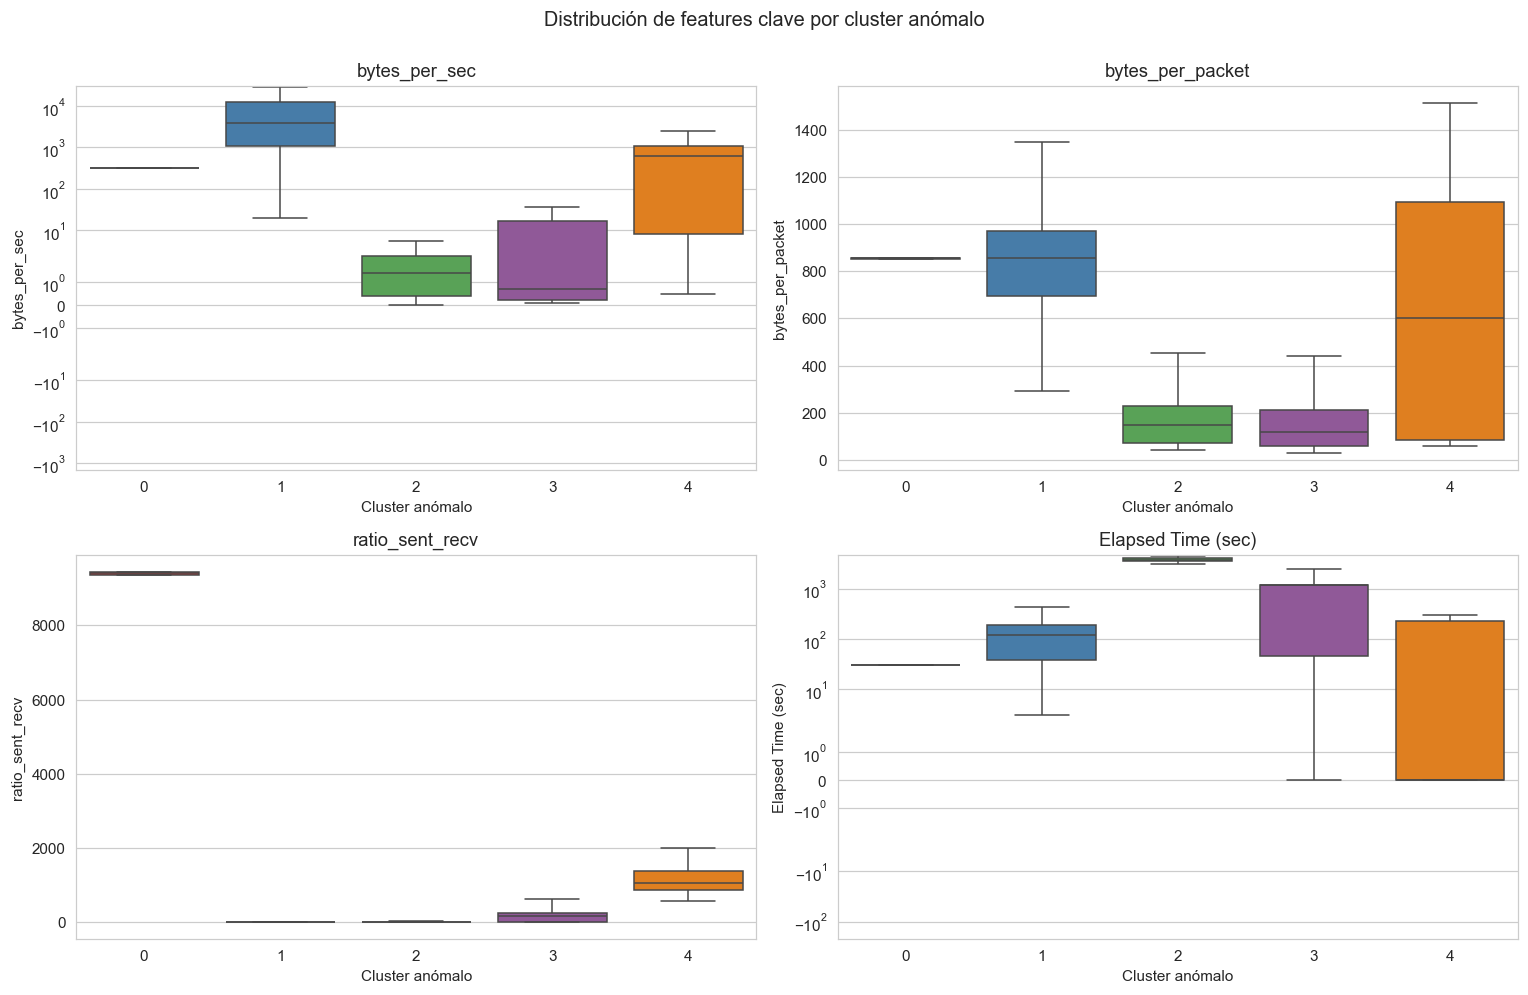

In [29]:
# ── Visualización 5: boxplots de features clave por cluster anómalo ──────
KEY_FEATURES_PLOT = ["bytes_per_sec", "bytes_per_packet",
                     "ratio_sent_recv", "Elapsed Time (sec)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
df_anom_plot = df.loc[mask_anomaly].copy()

for ax, feat in zip(axes.flat, KEY_FEATURES_PLOT):
    sns.boxplot(data=df_anom_plot, x="anomaly_cluster", y=feat,
                ax=ax, palette="Set1", showfliers=False)
    ax.set_title(feat); ax.set_xlabel("Cluster anómalo")
    if feat in ("bytes_per_sec", "Elapsed Time (sec)"):
        ax.set_yscale("symlog")

plt.suptitle("Distribución de features clave por cluster anómalo",
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


### 3.8 Validación cruzada: reglas H1..H11 vs clusters ML

Cuantificamos el solapamiento entre la detección por reglas (los hallazgos H1..H11
que produce la sección de análisis dirigido) y la detección por ML (clusters anómalos).

**Métricas que calculamos:**

- `n_solo_reglas`: registros flaggeados por al menos una H pero **NO** por IF
  → los hallazgos por reglas que el ML «pierde». Esperable: las reglas codifican
    conocimiento de dominio que el ML no infiere por sí solo (p.ej., puertos
    específicos que son sensibles aunque su tráfico estadísticamente parezca normal).
- `n_solo_ML`: registros marcados anómalos por IF pero **NO** por ninguna H
  → es la **plusvalía del ML**: anomalías que las reglas no cubren.
- `n_ambos`: intersección → señal más confiable, doble validación.

El heatmap muestra, para cada H, qué porcentaje cae en cada cluster — útil para
entender qué tipo de anomalía codifica cada regla.


In [ ]:
# ── Detección automática de columnas H1..H11 ─────────────────────────────
import re
H_COLS = sorted(
    [c for c in df.columns if re.fullmatch(r"H\d{1,2}(_crit|_med)?", str(c))]
    or [c for c in df.columns if re.fullmatch(r"H\d{1,2}", str(c))],
    key=lambda x: int(re.findall(r"\d+", x)[0]),
)

print(f"Columnas H detectadas ({len(H_COLS)}): {H_COLS}")


# rules_anomaly: cualquier H activo (mayoría son booleanos 0/1)
rules_anomaly = df[H_COLS].astype(bool).any(axis=1)

df["rules_anomaly"] = rules_anomaly
print(f"Registros marcados por reglas: {rules_anomaly.sum():,}")
print("─" * 70)


Columnas H detectadas (11): ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11']
Registros marcados por reglas: 19,281
──────────────────────────────────────────────────────────────────────


In [31]:
# ── Métricas de solapamiento reglas vs ML ────────────────────────────────
ml_anomaly = df["iso_label"] == -1

n_solo_reglas = (rules_anomaly & ~ml_anomaly).sum()
n_solo_ml     = (~rules_anomaly & ml_anomaly).sum()
n_ambos       = (rules_anomaly & ml_anomaly).sum()
n_ninguno     = (~rules_anomaly & ~ml_anomaly).sum()

resumen = pd.DataFrame({
    "Categoría": ["Solo reglas (ML las pierde)",
                  "Solo ML (plusvalía del ML)",
                  "Ambos (señal confiable)",
                  "Ninguno (normal)"],
    "n":         [n_solo_reglas, n_solo_ml, n_ambos, n_ninguno],
    "%":         [round(100*n/len(df), 2)
                  for n in (n_solo_reglas, n_solo_ml, n_ambos, n_ninguno)],
})
print(resumen.to_string(index=False))
print("─" * 70)

# Tasa de cobertura
if (rules_anomaly.sum() > 0):
    cobertura_ml_sobre_reglas = 100 * n_ambos / rules_anomaly.sum()
    print(f"Cobertura ML sobre reglas: {cobertura_ml_sobre_reglas:.1f}%")
if (ml_anomaly.sum() > 0):
    cobertura_reglas_sobre_ml = 100 * n_ambos / ml_anomaly.sum()
    print(f"Cobertura reglas sobre ML: {cobertura_reglas_sobre_ml:.1f}%")
print("─" * 70)


                  Categoría     n     %
Solo reglas (ML las pierde) 18250 27.85
 Solo ML (plusvalía del ML)  2246  3.43
    Ambos (señal confiable)  1031  1.57
           Ninguno (normal) 44005 67.15
──────────────────────────────────────────────────────────────────────
Cobertura ML sobre reglas: 5.3%
Cobertura reglas sobre ML: 31.5%
──────────────────────────────────────────────────────────────────────


Distribución (%) de cada hallazgo por cluster ML:
          n_total   C0    C1    C2    C3   C4   NoML
hallazgo                                            
H1          12891  0.0   0.0   0.0   0.0  0.0  100.0
H2             96  0.0   9.4   0.0   0.0  5.2   85.4
H3           1720  0.1   0.0  12.3  31.3  2.3   54.0
H4             48  0.0  93.8   6.2   0.0  0.0    0.0
H5             17  0.0   0.0   0.0   0.0  0.0  100.0
H6             14  0.0   0.0   7.1   0.0  0.0   92.9
H7            173  0.0   0.0   0.0  11.0  1.2   87.9
H8            909  0.0   0.0   0.0   0.0  0.0  100.0
H9             52  9.6  75.0   1.9   0.0  1.9   11.5
H10          4524  0.0   1.0   1.9  12.3  1.3   83.4
H11           937  0.0   0.0   0.0   0.0  0.0  100.0
──────────────────────────────────────────────────────────────────────


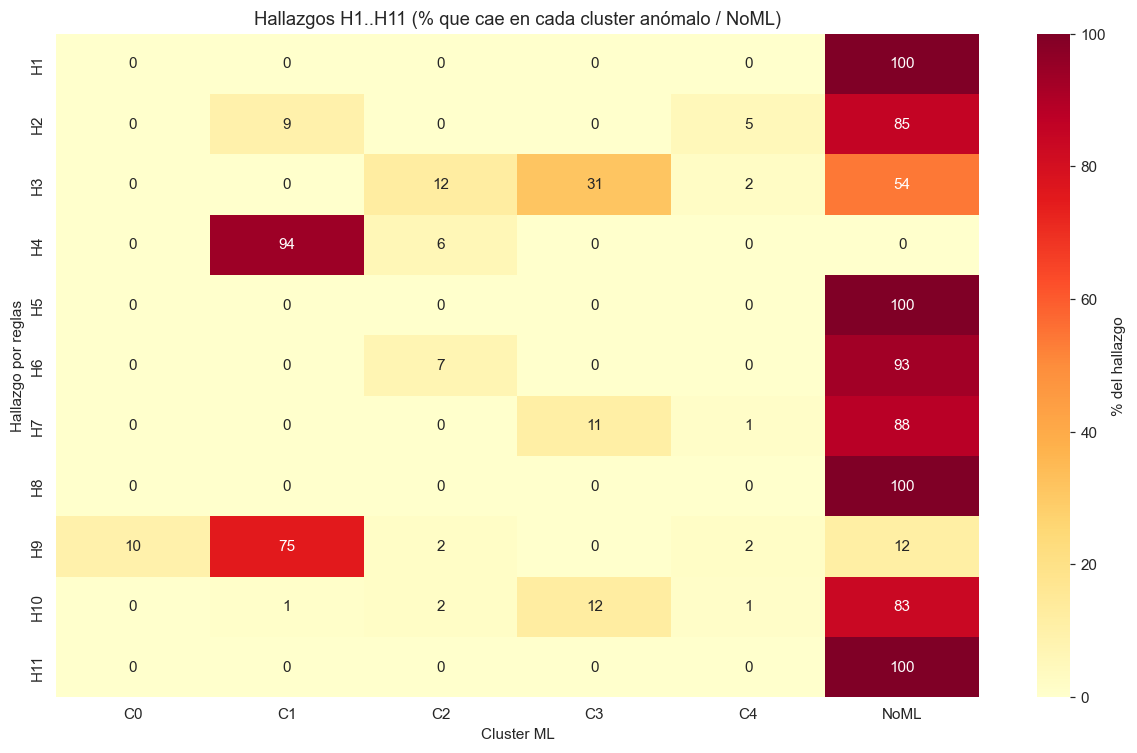

In [32]:
# ── Visualización 6: heatmap H1..H11 × clusters anómalos ─────────────────
if H_COLS:
    heatmap_data = []
    for h in H_COLS:
        mask_h = df[h].astype(bool)
        n_h = mask_h.sum()
        row = {"hallazgo": h, "n_total": int(n_h)}
        for c in sorted(df.loc[mask_anomaly, "anomaly_cluster"].unique()):
            mask_c = (df["anomaly_cluster"] == c) & mask_h
            row[f"C{c}"] = round(100 * mask_c.sum() / max(n_h, 1), 1)
        # Anomalías que NO entran en ningún cluster (porque IF las marcó normales)
        row["NoML"] = round(100 * (mask_h & ~ml_anomaly).sum() / max(n_h, 1), 1)
        heatmap_data.append(row)

    hm_df = pd.DataFrame(heatmap_data).set_index("hallazgo")
    print("Distribución (%) de cada hallazgo por cluster ML:")
    print(hm_df.to_string())
    print("─" * 70)

    # Plot
    plot_cols = [c for c in hm_df.columns if c != "n_total"]
    fig, ax = plt.subplots(figsize=(1.2 * len(plot_cols) + 4, 0.45 * len(H_COLS) + 2))
    sns.heatmap(hm_df[plot_cols], annot=True, fmt=".0f", cmap="YlOrRd",
                cbar_kws={"label": "% del hallazgo"}, ax=ax)
    ax.set_title("Hallazgos H1..H11 (% que cae en cada cluster anómalo / NoML)")
    ax.set_xlabel("Cluster ML"); ax.set_ylabel("Hallazgo por reglas")
    plt.tight_layout(); plt.show()
else:
    print("Heatmap omitido: no hay columnas H1..H11 detectadas.")


### 3.9 Ensemble y priorización en 5 niveles

Combinamos las señales en una variable `n_capas` que cuenta cuántas evidencias
independientes apuntan a la misma fila:

- `+1` si IF la marcó anómala
- `+1` si HDBSCAN la marcó como ruido (outlier extremo dentro del subconjunto anómalo)
- `+1` por cada H1..H11 que se active (ponderación: usamos `min(n_h, 3)` para no
  saturar — más de 3 reglas activas ya saturan la señal)

**Reglas de priorización:**

| Prioridad | Condición |
|---|---|
| `CRÍTICA` | `Action == allow` y `n_capas ≥ 3` → el firewall **permitió** tráfico que múltiples capas detectan como anómalo. Esto es un **fallo de política**. |
| `ALTA` | `Action == allow` y `n_capas == 2` |
| `MEDIA` | `Action == allow` y `n_capas == 1` |
| `BAJA` | `Action ∈ {deny, drop, reset-both}` con anomalía ML → el firewall ya lo bloqueó; investigar por completitud forense pero no urgente. |
| `NORMAL` | Sin flags |


In [33]:
# ── Cómputo de n_capas y prioridad ───────────────────────────────────────
def compute_layers(row) -> int:
    layers = 0
    if row["iso_label"] == -1:
        layers += 1
    if pd.notna(row.get("hdbscan_label")) and row["hdbscan_label"] == -1:
        layers += 1
    if H_COLS:
        n_h_active = sum(int(bool(row[h])) for h in H_COLS)
        layers += min(n_h_active, 3)
    return layers

df["n_capas"] = df.apply(compute_layers, axis=1)

def assign_priority(row) -> str:
    action  = row["Action"]
    layers  = row["n_capas"]
    is_anom = row["iso_label"] == -1 or row.get("rules_anomaly", False)

    if action == "allow":
        if layers >= 3: return "CRITICA"
        if layers == 2: return "ALTA"
        if layers == 1: return "MEDIA"
        return "NORMAL"
    else:  # deny / drop / reset-both
        if is_anom: return "BAJA"
        return "NORMAL"

df["prioridad"] = df.apply(assign_priority, axis=1)

# Resumen
prio_summary = (df["prioridad"]
                .value_counts()
                .reindex(["CRITICA","ALTA","MEDIA","BAJA","NORMAL"])
                .fillna(0).astype(int))
print("Distribución final de prioridades:")
for k, v in prio_summary.items():
    pct = 100 * v / len(df)
    print(f"  {k:<8} {v:>7,} ({pct:5.2f}%)")
print("─" * 70)


Distribución final de prioridades:
  CRITICA      766 ( 1.17%)
  ALTA         807 ( 1.23%)
  MEDIA      4,434 ( 6.77%)
  BAJA      15,520 (23.68%)
  NORMAL    44,005 (67.15%)
──────────────────────────────────────────────────────────────────────


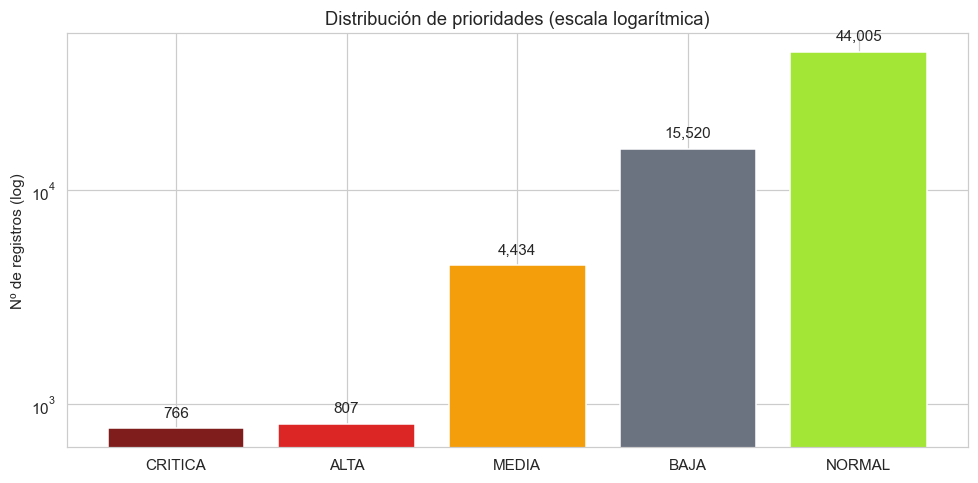

In [34]:
# ── Visualización 7 (bonus): barplot de prioridades con escala log ───────
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_prio = {
    "CRITICA": "#7f1d1d",
    "ALTA":    "#dc2626",
    "MEDIA":   "#f59e0b",
    "BAJA":    "#6b7280",
    "NORMAL":  "#a3e635",
}
bars = ax.bar(
    prio_summary.index, prio_summary.values,
    color=[colors_prio[k] for k in prio_summary.index],
    edgecolor="white",
)
ax.set_yscale("log")
ax.set_title("Distribución de prioridades (escala logarítmica)")
ax.set_ylabel("Nº de registros (log)")
for bar, val in zip(bars, prio_summary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.1,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()


### 3.10 Export CSV para cruce con Network Flows

**Dependencia con el notebook posterior de cruce:**

```
fw_allow_ports    = ports where Action='allow' in firewall_anomalias_clasificadas.csv
nf_anomaly_ports  = ports where severity ∈ {critical, anomaly}
                    in network_flows_anomalias_clasificadas.csv
falsos_negativos  = fw_allow_ports ∩ nf_anomaly_ports
```

El campo `Destination Port` del firewall se cruza con `Destination.Port` del CSV de
Network Flows. Los puertos que aparecen como `allow` en firewall **y** como
crítico/anómalo en NF son **fallos de política de seguridad**: tráfico que el firewall
deja pasar pero el modelo estadístico de los flujos lo detecta como atípico.

Por tanto, **es obligatorio conservar la columna `Action`** y mantener `Destination Port`
con el mismo nombre exacto que en el resto de notebooks.


In [ ]:
# ── Construcción del DataFrame de export ─────────────────────────────────
EXPORT_COLS = [
    "Source Port", "Destination Port", "Action",
    "Bytes", "Bytes Sent", "Bytes Received",
    "Packets", "Elapsed Time (sec)",
    "pkts_sent", "pkts_received",
    "bytes_per_packet", "bytes_per_sec", "ratio_sent_recv",
    "iso_score", "iso_label",
    "anomaly_cluster", "cluster_name",
    "rules_anomaly", "n_capas", "prioridad",
]

export_df = df[EXPORT_COLS].copy()

# Cabecera explicativa en el filename / docstring
EXPORT_PATH = "/Datos/Transformados/firewall_anomalias_clasificadas.csv"
export_df.to_csv(EXPORT_PATH, index=False)

print(f"[OK] CSV exportado: {EXPORT_PATH}")
print(f"     Shape: {export_df.shape}")
print(f"     Columnas: {list(export_df.columns)}")
print("─" * 70)

# Sanity checks finales
print("Sanity checks:")
print(f"  - Filas con prioridad CRÍTICA: "
      f"{(export_df['prioridad']=='CRITICA').sum():,}")
print(f"  - Filas con Action=allow + ML anómalo: "
      f"{((export_df['Action']=='allow') & (export_df['iso_label']==-1)).sum():,}")
print(f"  - Filas con anomaly_cluster válido (>=0): "
      f"{(export_df['anomaly_cluster']>=0).sum():,}")
print(f"  - Filas con cluster_name != 'Normal': "
      f"{(export_df['cluster_name']!='Normal').sum():,}")

# Recordatorio para el notebook de cruce
print()
print("══════ DEPENDENCIA DOCUMENTADA ══════")
print("Este CSV se cruza con network_flows_anomalias_clasificadas.csv en el")
print("notebook posterior de correlación firewall ↔ flujos:")
print()
print("  fw  = pd.read_csv('Datos/Originales/firewall_anomalias_clasificadas.csv')")
print("  nf  = pd.read_csv('Datos/Originales/network_flows_anomalias_clasificadas.csv')")
print("  fw_allow_ports   = set(fw.loc[fw.Action=='allow', 'Destination Port'])")
print("  nf_anomaly_ports = set(nf.loc[nf['severity'].isin(['critical','anomaly']),")
print("                                'Destination.Port'])")
print("  falsos_negativos = fw_allow_ports & nf_anomaly_ports")
print()
print("→ falsos_negativos = puertos permitidos por firewall pero detectados")
print("  estadísticamente como anómalos en los flujos = fallos de política.")
print("═" * 36)


[OK] CSV exportado: firewall_anomalias_clasificadas.csv
     Shape: (65532, 20)
     Columnas: ['Source Port', 'Destination Port', 'Action', 'Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent', 'pkts_received', 'bytes_per_packet', 'bytes_per_sec', 'ratio_sent_recv', 'iso_score', 'iso_label', 'anomaly_cluster', 'cluster_name', 'rules_anomaly', 'n_capas', 'prioridad']
──────────────────────────────────────────────────────────────────────
Sanity checks:
  - Filas con prioridad CRÍTICA: 766
  - Filas con Action=allow + ML anómalo: 3,109
  - Filas con anomaly_cluster válido (>=0): 3,277
  - Filas con cluster_name != 'Normal': 3,277

══════ DEPENDENCIA DOCUMENTADA ══════
Este CSV se cruza con network_flows_anomalias_clasificadas.csv en el
notebook posterior de correlación firewall ↔ flujos:

  fw  = pd.read_csv('firewall_anomalias_clasificadas.csv')
  nf  = pd.read_csv('network_flows_anomalias_clasificadas.csv')
  fw_allow_ports   = set(fw.loc[fw.Action=='al

### 3.11 Conclusiones de la sección no supervisada

Resumen de lo que esta arquitectura aporta sobre la versión anterior:

1. **Orden correcto:** primero separamos (IF), luego agrupamos (K-Means / HDBSCAN
   solo sobre anomalías). Los clusters resultantes son interpretables y no están
   diluidos por la masa normal.

2. **Justificación empírica del umbral:** el histograma de `iso_score` (§3.3)
   evidencia si la distribución es bimodal (consistente con Action allow vs
   deny/drop) y, por tanto, si `contamination=0.05` fijo es defendible.
   En NF, donde la distribución era unimodal y estrecha, optamos por calibración
   por percentil del gradiente — aquí no hace falta.

3. **Caracterización operativa:** Cohen's d identifica qué features discriminan
   cada cluster y permite asignar etiquetas como "Exfiltración asimétrica",
   "Beaconing C2", "Burst de throughput", etc. — útiles para un analista SOC.

4. **Validación cruzada reglas vs ML:** el heatmap H1..H11 × clusters cuantifica:
   - qué reglas pierde el ML (limitación esperable: el ML no codifica conocimiento
     de dominio sobre puertos sensibles),
   - qué anomalías detecta el ML que las reglas no cubren (**plusvalía**).

5. **Priorización en 5 niveles:** la prioridad CRÍTICA aísla el caso más
   accionable — `allow` con ≥3 capas independientes señalándolo, que es donde
   un fallo de política de firewall causa daño real.

6. **CSV listo para cruce con NF:** las columnas `Destination Port` + `Action`
   permiten identificar **falsos negativos del firewall** comparando con los
   puertos que el modelo estadístico de Network Flows marca como críticos.


## 4. Conclusiones operativas para el SOC

Este notebook combina dos capas independientes de detección — reglas de dominio
(H1..H11) y aprendizaje no supervisado (Isolation Forest + clustering jerárquico
sobre el subconjunto anómalo) — y las fusiona en una **priorización en 5 niveles**
accionable.

**Lectura del CSV `firewall_anomalias_clasificadas.csv` por un analista SOC:**

1. **Filtrar `prioridad == 'CRITICA'`.** Son las filas donde el firewall hizo
   `allow` y al menos tres capas independientes (IF, HDBSCAN como outlier extremo,
   y/o múltiples Hk) coinciden marcándolas como anómalas. Son **fallos de política
   del firewall** que un atacante ya está explotando o podría explotar.

2. **Revisar `prioridad == 'ALTA'`.** Allow con 2 capas — sospechosos confirmados
   por dos fuentes independientes; investigación dentro del SLA estándar.

3. **`prioridad == 'MEDIA'`.** Allow con 1 capa — candidatos a revisión por
   muestreo o ante un incidente correlacionado.

4. **`prioridad == 'BAJA'`.** Deny/drop con anomalía ML — el firewall ya bloqueó,
   pero el patrón confirma actividad reconocedora o malware intentando salir.
   Útil para hardening reactivo y trazabilidad forense.

5. **Cruce con Network Flows.** El bloque final del export (sección 3.10) documenta
   el join contra `network_flows_anomalias_clasificadas.csv`. Los puertos
   permitidos por firewall que NF marca como críticos/anómalos son **falsos
   negativos de la política actual** y deberían añadirse al ciclo de revisión
   de reglas del cortafuegos.

**Qué no resuelve este notebook (límites honestos):**

- El firewall no contiene timestamps ni IPs → no podemos reconstruir kill chains
  temporales ni atribuir actores. Para eso depende de Network Flows como fuente
  primaria.
- Los nombres de cluster son heurísticas sobre Cohen's d; refinarlos requiere
  contexto de negocio (qué puertos son legítimos en esta planta industrial,
  cuáles son los hosts de gestión, etc.).
- El umbral `contamination=0.05` es defendible (ver §3.3) pero conservador: si
  el operador prefiere mayor sensibilidad puede subirlo a 0.07 sin que la
  arquitectura cambie.
